In [30]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from palmerpenguins import load_penguins
from sklearn.preprocessing import StandardScaler

from pymc_prop import sample_pro

FIGSIZE = (6.5, 4.0)
COLOR_DATA = "0.6"
COLOR_PRO = "#bca0ff"
PRO_CMAP = LinearSegmentedColormap.from_list("white_to_pro", ["white", COLOR_PRO])
N_LEVELS = 6
BW_ADJUST_1D = 2.0
BW_ADJUST_2D = 0.75
PAD_2D = 0.4

SEEDS = [0, 1, 2, 3, 4]
JITTER = 0.1
N_PARTICLES = 40
N_STEPS = 1500
STEP_SIZE = 2e-3
BURN_IN = 0


In [31]:
penguins = load_penguins()
cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df = penguins.dropna(subset=["sex", *cols])
df = df[df["sex"].isin(["male", "female"])].copy()

scaler = StandardScaler()
X = scaler.fit_transform(df[cols].values)
y = (df["sex"].values == "male").astype(int)
print(f"n = {len(df)}")

with pm.Model() as model:
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, shape=5)
    logit_p = beta[0] + pt.dot(X, beta[1:])
    pm.Bernoulli("sex", logit_p=logit_p, observed=y)


n = 333


In [32]:
def mean_pairwise_distance(particles):
    d = np.linalg.norm(particles[:, None, :] - particles[None, :, :], axis=-1)
    iu = np.triu_indices(len(particles), k=1)
    return d[iu].mean()


def run_case(init, seed, jitter=JITTER):
    result = sample_pro(
        model=model,
        init=init,
        jitter=jitter,
        n_particles=N_PARTICLES,
        n_steps=N_STEPS,
        burn_in=BURN_IN,
        thinning=1,
        step_size=STEP_SIZE,
        learning_rate=1.0,
        random_seed=seed,
    )
    traj = result.particles
    return {
        "init": init,
        "seed": seed,
        "jitter": jitter,
        "traj": traj,
        "t0_spread": mean_pairwise_distance(traj[0]),
        "final_spread": mean_pairwise_distance(traj[-1]),
        "final": traj[-1],
    }


records = []
for seed in SEEDS:
    records.append(run_case("jitter", seed))
    records.append(run_case("prior", seed))

for jitter in [0.01, 0.5]:
    records.append(run_case("jitter", seed=0, jitter=jitter))

summary = pd.DataFrame(
    {
        "init": [r["init"] for r in records],
        "seed": [r["seed"] for r in records],
        "jitter": [r["jitter"] for r in records],
        "t0_spread": [r["t0_spread"] for r in records],
        "final_spread": [r["final_spread"] for r in records],
    }
)
summary


,init,seed,jitter,t0_spread,final_spread
0,jitter,0,0.10,0.334948,1.732648
1,prior,0,0.10,3.319805,1.821019
2,jitter,1,0.10,0.328820,1.844010
3,prior,1,0.10,2.693625,1.822299
4,jitter,2,0.10,0.355850,1.964818
5,prior,2,0.10,3.088964,1.983974
6,jitter,3,0.10,0.368999,1.972778
7,prior,3,0.10,3.095512,2.050186
8,jitter,4,0.10,0.360318,1.877506
9,prior,4,0.10,2.847313,1.798271


In [33]:
def finals_for(init, jitter=JITTER):
    return np.concatenate(
        [r["final"] for r in records if r["init"] == init and r["jitter"] == jitter],
        axis=0,
    )


def record_for(init, seed=0, jitter=JITTER):
    return next(
        r for r in records if r["init"] == init and r["seed"] == seed and r["jitter"] == jitter
    )


def beta_limits(pts_list, pad=PAD_2D):
    pts = np.vstack(pts_list)[:, :2]
    return (
        (pts[:, 0].min() - pad, pts[:, 0].max() + pad),
        (pts[:, 1].min() - pad, pts[:, 1].max() + pad),
    )


def plot_beta_cloud(ax, pts, xlim, ylim, title):
    if len(pts) >= 5:
        sns.kdeplot(
            x=pts[:, 0],
            y=pts[:, 1],
            ax=ax,
            fill=True,
            cmap=PRO_CMAP,
            levels=N_LEVELS,
            thresh=0.05,
            bw_adjust=BW_ADJUST_2D,
        )
    sns.scatterplot(
        x=pts[:, 0],
        y=pts[:, 1],
        s=8,
        alpha=0.6,
        color="black",
        legend=False,
        ax=ax,
    )
    ax.set(xlim=xlim, ylim=ylim, title=title, xlabel=r"$\beta_0$", ylabel=r"$\beta_1$ (bill length)")


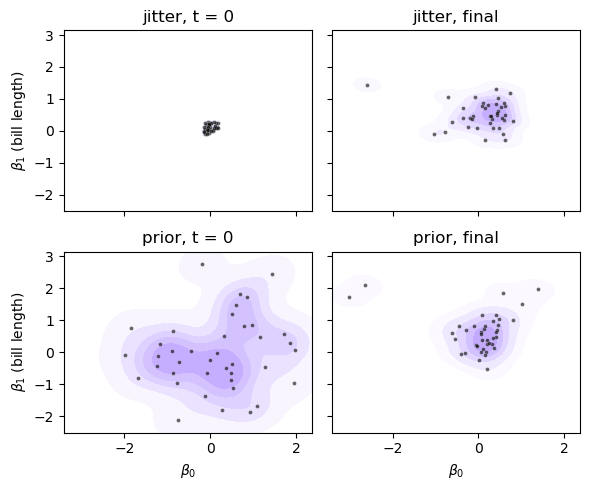

In [34]:
rep_j = record_for("jitter")
rep_p = record_for("prior")
xlim, ylim = beta_limits([
    rep_j["traj"][0][:, :2], rep_j["traj"][-1][:, :2],
    rep_p["traj"][0][:, :2], rep_p["traj"][-1][:, :2],
])

fig, axes = plt.subplots(2, 2, figsize=(6, 5), sharex=True, sharey=True)
for row, init in enumerate(["jitter", "prior"]):
    traj = record_for(init)["traj"]
    for col, idx, tlabel in zip(range(2), [0, -1], ["t = 0", "final"]):
        plot_beta_cloud(axes[row, col], traj[idx][:, :2], xlim, ylim, f"{init}, {tlabel}")
plt.tight_layout()
plt.show()


/tmp/ipykernel_658092/1403793057.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


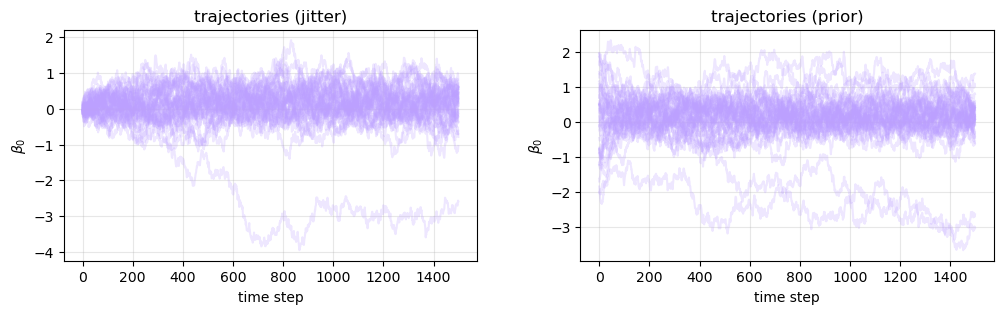

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={"wspace": 0.25})
for ax, init in zip(axes, ["jitter", "prior"]):
    traj = record_for(init)["traj"]
    steps = np.arange(traj.shape[0])
    for j in range(traj.shape[1]):
        ax.plot(steps, traj[:, j, 0], color=COLOR_PRO, alpha=0.25)
    ax.set(title=f"trajectories ({init})", xlabel="time step", ylabel=r"$\beta_0$")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


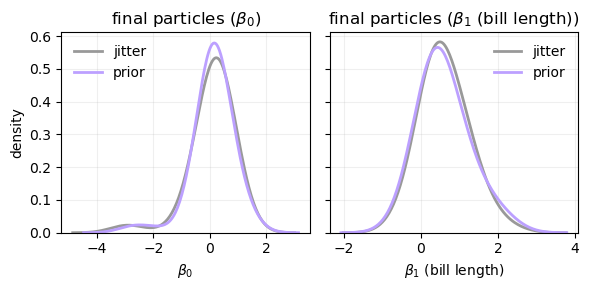

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
labels = [r"$\beta_0$", r"$\beta_1$ (bill length)"]
for ax, dim, xlab in zip(axes, [0, 1], labels):
    for init, color in [("jitter", COLOR_DATA), ("prior", COLOR_PRO)]:
        sns.kdeplot(
            x=finals_for(init)[:, dim],
            ax=ax,
            color=color,
            linewidth=2,
            bw_adjust=BW_ADJUST_1D,
            label=init,
        )
    ax.set(title=f"final particles ({xlab})", xlabel=xlab, ylabel="density")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


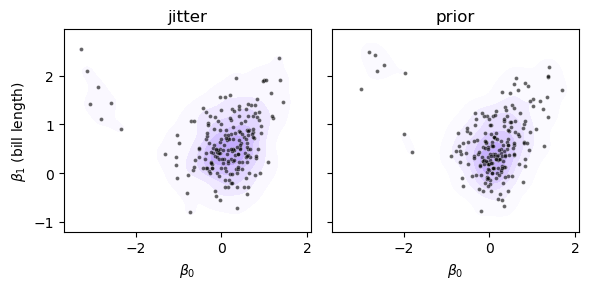

In [37]:
all_pts = np.vstack([finals_for("jitter")[:, :2], finals_for("prior")[:, :2]])
xlim, ylim = beta_limits([all_pts])

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)
for ax, init in zip(axes, ["jitter", "prior"]):
    plot_beta_cloud(ax, finals_for(init)[:, :2], xlim, ylim, init)
plt.tight_layout()
plt.show()


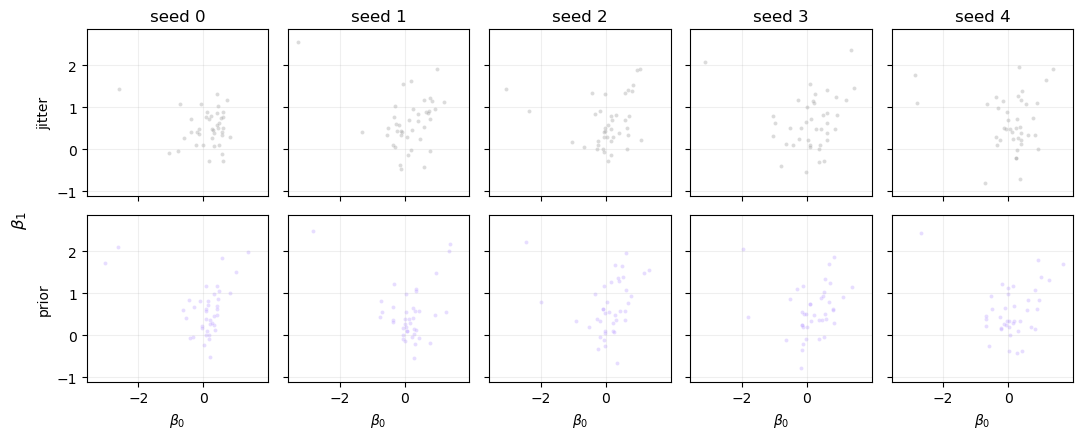

In [38]:
fig, axes = plt.subplots(2, len(SEEDS), figsize=(2.2 * len(SEEDS), 4.5), sharex=True, sharey=True)
all_pts = np.vstack([
    record_for(init, seed=seed)["final"][:, :2]
    for init in ("jitter", "prior")
    for seed in SEEDS
])
xlim, ylim = beta_limits([all_pts], pad=0.3)
for row, init in enumerate(["jitter", "prior"]):
    for col, seed in enumerate(SEEDS):
        ax = axes[row, col]
        pts = record_for(init, seed=seed)["final"][:, :2]
        color = COLOR_PRO if init == "prior" else COLOR_DATA
        sns.scatterplot(x=pts[:, 0], y=pts[:, 1], s=8, alpha=0.35, color=color, legend=False, ax=ax)
        ax.set(xlim=xlim, ylim=ylim)
        if row == 0:
            ax.set_title(f"seed {seed}")
        if col == 0:
            ax.set_ylabel(init)
        if row == 1:
            ax.set_xlabel(r"$\beta_0$")
        ax.grid(alpha=0.2)
fig.supylabel(r"$\beta_1$", x=0.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_658092/553150607.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


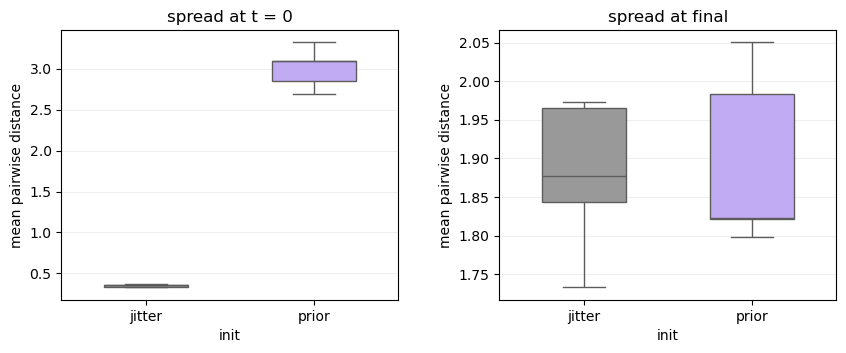

In [39]:
plot_df = summary[summary["jitter"] == JITTER].copy()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), gridspec_kw={"wspace": 0.3})
palette = {"jitter": COLOR_DATA, "prior": COLOR_PRO}
for ax, metric, title in zip(
    axes,
    ["t0_spread", "final_spread"],
    ["spread at t = 0", "spread at final"],
):
    sns.boxplot(
        data=plot_df,
        x="init",
        y=metric,
        hue="init",
        palette=palette,
        legend=False,
        width=0.5,
        ax=ax,
    )
    ax.set(title=title, xlabel="init", ylabel="mean pairwise distance")
    ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()


In [40]:
jitter_sens = (
    summary[summary["init"] == "jitter"]
    .groupby("jitter", as_index=False)[["t0_spread", "final_spread"]]
    .mean()
    .sort_values("jitter")
)
jitter_sens


,jitter,t0_spread,final_spread
0,0.01,0.192711,1.732423
1,0.10,0.349787,1.878352
2,0.50,1.442504,1.761785
